In [1]:
import numpy as np
import pickle
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from statsmodels.stats.stattools import durbin_watson

In [3]:
with open('all_variables.pkl', 'rb') as f:
    r2_df = pickle.load(f)

In [4]:
import nibabel as nb

In [21]:
ts_files = glob('/pscratch/sd/m/mphagen/hcp-functional-connectivity/derivatives/timeseries/xcpd/sub-*/*ses-1*ptseries.nii')

In [6]:
sub_list = []
_ = [sub_list.append(ii.split('/')[-2]) for ii in ts_files]

In [10]:
len(ts_files) 

1084

In [22]:
ts_files.sort()

In [24]:
ts_files[10]

'/pscratch/sd/m/mphagen/hcp-functional-connectivity/derivatives/timeseries/xcpd/sub-102109/sub-102109_task-rest_ses-1_space-fsLR_seg-4S156Parcels_den-91k_stat-mean_timeseries.ptseries.nii'

In [25]:
cifti = nb.load(ts_files[10])
cifti_data = cifti.get_fdata(dtype=np.float32)

In [30]:
#cifti data is zero indexed, so node_7 in 2025-11-04 is actually node 8

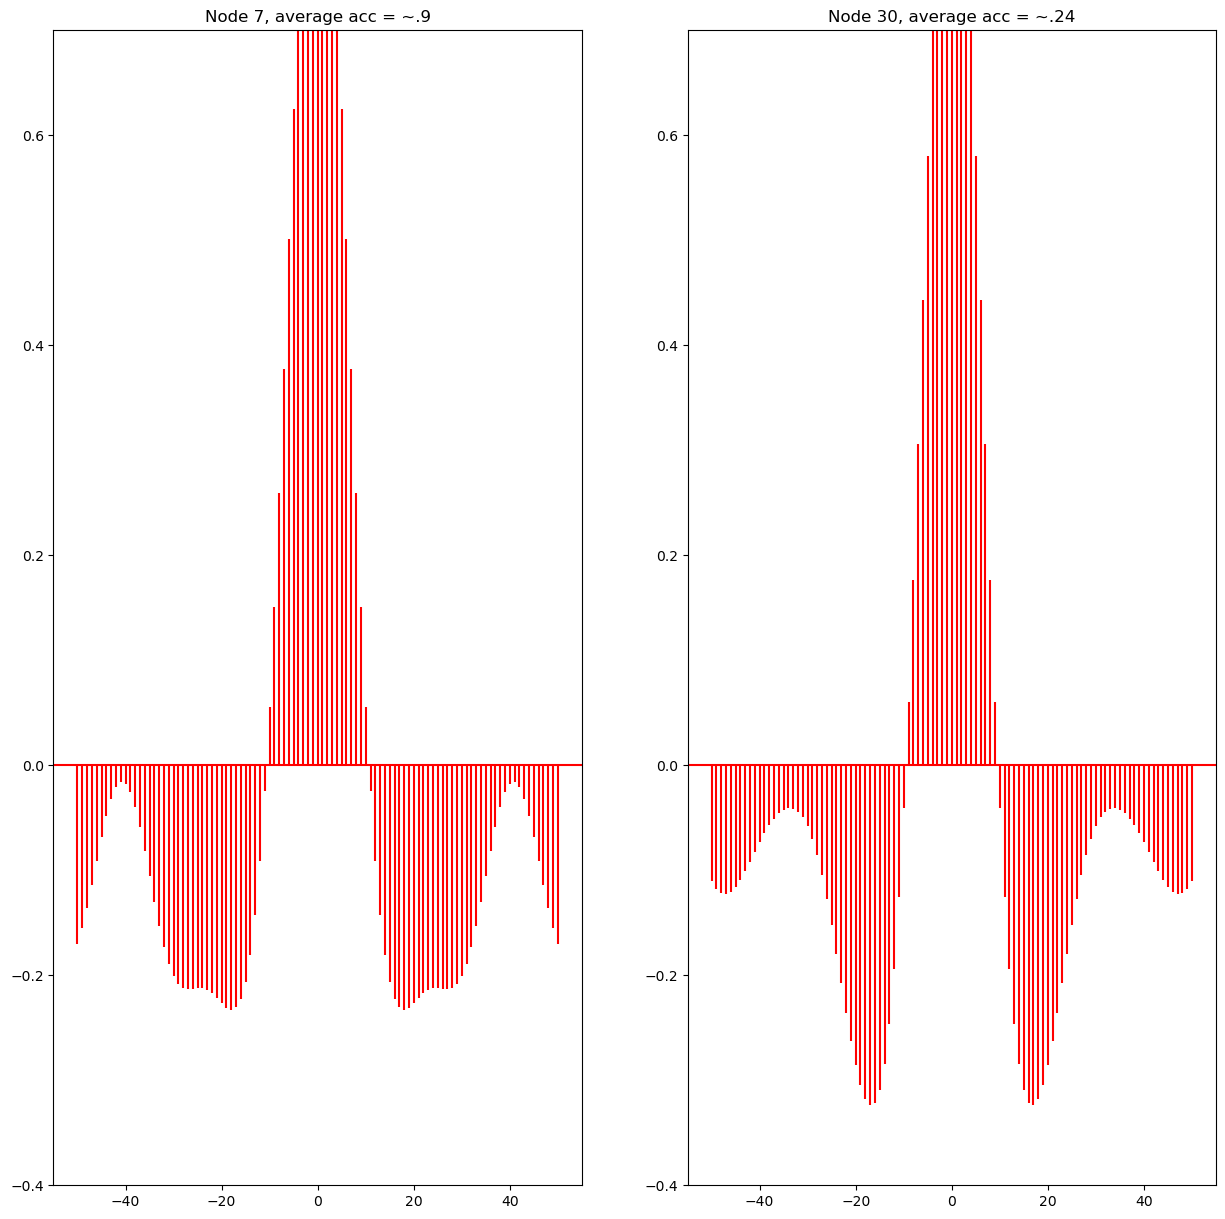

In [55]:
fig, ax = plt.subplots(1,2, figsize=(15,15) ) 

ax[0].xcorr(cifti_data[:,8], cifti_data[:,8], color='red', maxlags=50)
ax[0].set_ylim([-.4, .7])
ax[0].set_title('Node 7, average acc = ~.9')
# ax[1,1].xcorr(cifti[:,70], cifti[:,70],   color='blue', maxlags=2399) 

# ax[0,1].xcorr(cifti[:,30], cifti[:,70], color='purple', maxlags=2399) 
ax[1].set_title('Node 30, average acc = ~.24')

ax[1].xcorr(cifti_data[:,31], cifti_data[:,31], color='red', maxlags=50) 
# ax[1,0].xcorr(cifti[:,30], cifti[:,30], color='blue', maxlags=2399) 
ax[1].set_ylim([-.4, .7])

plt.savefig('sub-102109_autocorrelation_lag500.png') 


In [64]:
data = cifti_data

In [66]:
cifti_data.shape

(2400, 156)

In [65]:
meanimg = np.mean(data, axis=3)
stddevimg = np.std(data, axis=3)
tsnr = np.zeros_like(meanimg)
stddevimg_nonzero = stddevimg > 1.0e-3
tsnr[stddevimg_nonzero] = (
    meanimg[stddevimg_nonzero] / stddevimg[stddevimg_nonzero]) 

AxisError: axis 3 is out of bounds for array of dimension 2

In [62]:
for ii in range(0, 99): 
    print(np.mean(cifti_data[:,ii])  / np.std(cifti_data[:,ii]) ) 

-0.008588333
-0.003949715
-0.0022432655
0.0041733654
-0.011507644
0.0009456919
-0.013776584
-0.0019473142
0.00049292896
0.0044409903
-0.0052402806
-0.010721886
-0.0021444664
-0.0029249364
-0.0029828346
-0.01248536
-0.011836047
-0.0068348204
-0.008743545
-0.008214812
-0.015503587
0.0008354411
-0.0016932995
-0.006308561
0.0011475828
0.0027202582
0.005661653
0.011329526
0.0025638759
0.0048693726
0.004803253
0.00996824
0.007519161
-0.005317074
-0.0047283783
-0.008128087
0.004381123
0.004539103
0.011886483
-0.018278424
0.0068047503
0.008815542
0.009434089
0.01623698
0.0070649525
0.01794091
0.0053483937
0.007353154
-0.0048123584
-0.0035017899
-0.0043107155
-0.0062545496
-0.0026702157
0.0032717397
-0.008833815
-0.0025509472
0.0011886499
-0.0022676983
0.001733057
-0.0084121525
-0.0016017521
-0.0030963866
0.006654854
-0.005797757
-0.009645235
-0.0017844444
-0.0181904
-0.011082998
-0.007051604
-0.0030102052
-0.012158848
-0.0009570778
-0.006262619
-0.012698885
-0.012086969
-0.0019711927
-0.006470